# Qualitative features notebook

## Generating test data

In [2]:
import os
# Specify the desired number of images
desired_count = 5

# Generate images one by one until the desired count is reached
while True:
    !python3 ../samples_generator/samples_generator.py --num_images 5 --img_size 500 --specified_angle 90 --output_dir ../../tests/generated_samples/
    !python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/

    # Check the number of files in the folder
    path, dirs, files = next(os.walk("../../tests/generated_samples/"))
    file_count = len(files)
    print(f"Total images: {file_count}")

    # Break the loop if the desired count is reached
    if file_count >= desired_count:
        break

print(f"Number of test images: {file_count}")

5 images have been saved to ../../tests/generated_samples//
Total images: 2
5 images have been saved to ../../tests/generated_samples//
Total images: 4
5 images have been saved to ../../tests/generated_samples//
Total images: 6
Number of test images: 6


### Generate squares

In [ ]:
import os

# Generate 500 images of size 100x100
!python3 ../samples_generator/square_generator.py --num_images 200 --img_size 250 --output_dir ../../tests/squares/
!python3 ../line_detector/line_detector.py --folder_path ../../tests/squares/ --num_lines 4

# Calculating number of test images
path, dirs, files = next(os.walk("../../tests/squares/"))
file_count = len(files)
print(f"Number of test images: {file_count}")

### Generate squares

In [ ]:
import os

# Generate 500 images of size 100x100
!python3 ../samples_generator/square_generator.py --num_images 10 --img_size 250 --output_dir ../../tests/squares/

## Analyze training results

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../../training_results/qualitative_features.csv')

# Ensure node_id is a string to prevent any unintended type interpretations
df['node_id'] = df['node_id'].astype(str)
df['labels'] = df['labels'].astype(str)  # Ensure labels are treated as string

# Combine 'node_id' and 'labels' for a unique identifier and legend information
df['node_label'] = df['node_id'] + " - " + df['labels']

# Get the latest (or max) relation count for each node_label to order the legend
latest_relation_count = df.groupby('node_label')['relation_count'].max().sort_values(ascending=False)

# Create a sorted list of node_labels based on the latest relation count
sorted_node_labels = latest_relation_count.index.tolist()

# Pivot the DataFrame to have iterations as index and each unique node_label as a column
pivot_df = df.pivot_table(index='iteration', columns='node_label', values='relation_count', aggfunc='max')

# Reorder pivot_df columns based on the sorted node_labels
pivot_df = pivot_df[sorted_node_labels]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot and use the colormap for a wider variety of colors
pivot_df.plot(kind='line', ax=ax, cmap='tab10')

# Title and labels
plt.title('Number of Inbound Links per Node Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Inbound Links')

# Adjust legend - Since we have combined node_id and labels, it will show both
plt.legend(title='Node ID - Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

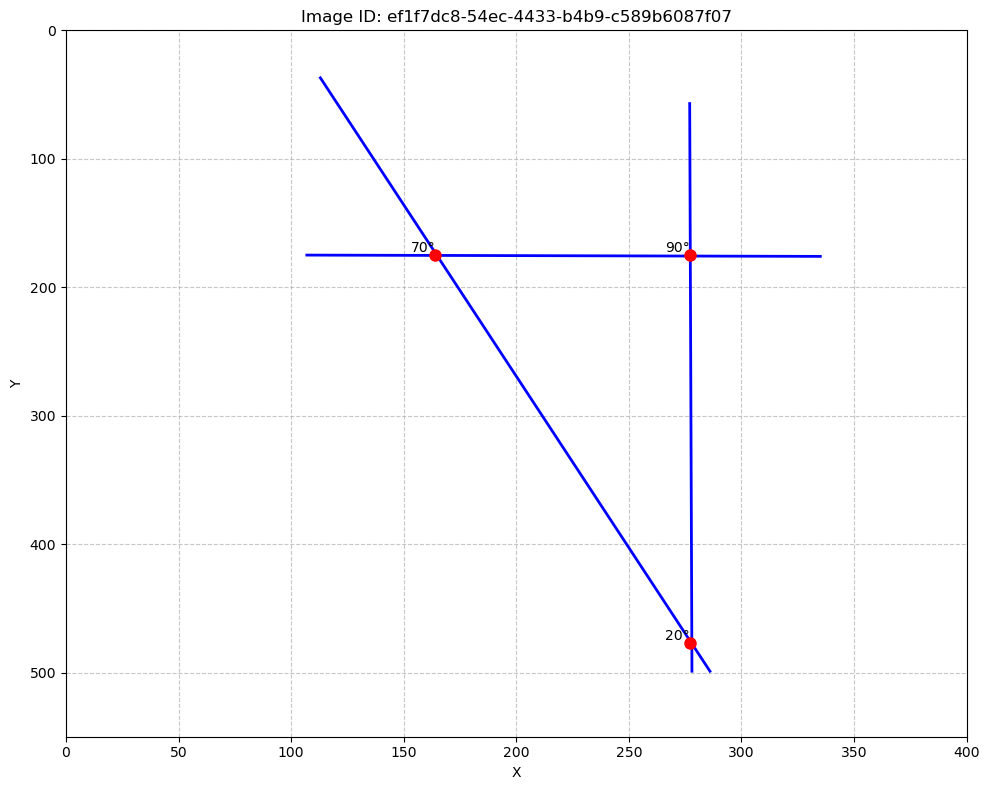

In [2]:
import json
import matplotlib.pyplot as plt

# Your JSON data as a string (remove the timestamps)
json_str = '''
{
	"image_id": "ef1f7dc8-54ec-4433-b4b9-c589b6087f07",
	"lines": [
		{
			"id": "3b2d2653-ff9d-412e-8937-e97ec6ad6523",
			"x1": 107,
			"y1": 175,
			"x2": 335,
			"y2": 176,
			"length": 228
		},
		{
			"id": "46984248-3a59-4fc9-bd89-bcb35576bd8a",
			"x1": 113,
			"y1": 37,
			"x2": 286,
			"y2": 499,
			"length": 493
		},
		{
			"id": "71ab27aa-b1fe-4903-a52d-ab9ca57c8ac6",
			"x1": 277,
			"y1": 57,
			"x2": 278,
			"y2": 499,
			"length": 442
		}
	],
	"angle_points": [
		{
			"id": "b5b9172e-c762-4dde-98bd-d53a78da2243",
			"x": 164,
			"y": 175,
			"angle": 70,
			"line1": "3b2d2653-ff9d-412e-8937-e97ec6ad6523",
			"line2": "46984248-3a59-4fc9-bd89-bcb35576bd8a"
		},
		{
			"id": "97e370d6-8a0b-4abc-832a-1b0bc9c51684",
			"x": 277,
			"y": 175,
			"angle": 90,
			"line1": "3b2d2653-ff9d-412e-8937-e97ec6ad6523",
			"line2": "71ab27aa-b1fe-4903-a52d-ab9ca57c8ac6"
		},
		{
			"id": "d75ce7f0-b0a3-4e8a-bcf6-ae2eb9441ff7",
			"x": 277,
			"y": 477,
			"angle": 20,
			"line1": "46984248-3a59-4fc9-bd89-bcb35576bd8a",
			"line2": "71ab27aa-b1fe-4903-a52d-ab9ca57c8ac6"
		}
	]
}
'''

# Parse the JSON data
data = json.loads(json_str)

# Create a new figure
plt.figure(figsize=(10, 8))

# Plot lines
for line in data['lines']:
    plt.plot([line['x1'], line['x2']], [line['y1'], line['y2']], 'b-', linewidth=2)

# Plot angle points
for point in data['angle_points']:
    plt.plot(point['x'], point['y'], 'ro', markersize=8)
    plt.text(point['x'], point['y'], f"{point['angle']}°", fontsize=10, ha='right', va='bottom')

# Set the axis limits
plt.xlim(0, 400)
plt.ylim(0, 550)

# Invert the y-axis to match image coordinates
plt.gca().invert_yaxis()

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Image ID: {data['image_id']}")

# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()